# Import các thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Mining

### Bước 1: Đọc dữ liệu từ file CSV đã tiền xử lý

In [2]:
df = pd.read_csv('car_sales_data_cleaned.csv')

df.head(5)

,brand,model,engine_size,fuel_type,year,mileage_km,price_usd,age,price_per_1k_km,mileage_bucket_label,mileage_bucket_order,age_bucket_label,age_bucket_order,overprice_threshold,is_overpriced
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,23,24.147683,>100k,4,10y+,4,24653.000,False
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,9,859.187554,50-100k,3,6-10y,3,73239.750,False
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,11,614.238326,20-50k,2,10y+,4,43916.000,False
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,37,8.087698,>100k,4,10y+,4,66286.875,False
4,VW,Polo,1.0,Petrol,2006,127869,4101,19,32.071886,>100k,4,10y+,4,26969.875,False


In [3]:
print("Tổng số bản ghi:", len(df))

Tổng số bản ghi: 50000


In [4]:
print("Các cột trong dataset:")
print(df.columns)

Các cột trong dataset:
Index(['brand', 'model', 'engine_size', 'fuel_type', 'year', 'mileage_km',
       'price_usd', 'age', 'price_per_1k_km', 'mileage_bucket_label',
       'mileage_bucket_order', 'age_bucket_label', 'age_bucket_order',
       'overprice_threshold', 'is_overpriced'],
      dtype='object')


### Bước 2: Phân tích tương quan và lựa chọn thuộc tính đầu vào

Mục tiêu của bước này là lựa chọn được tập thuộc tính đầu vào (features) **vừa giàu thông tin, vừa tránh trùng lặp hoặc rò rỉ dữ liệu** khi dự đoán `price_usd`. Nhóm kết hợp hai hướng:

1. Phân tích tương quan và trực quan hóa dữ liệu.
2. Kết hợp với hiểu biết nghiệp vụ về thị trường xe cũ.

#### 2.1. Phân tích tương quan giữa các thuộc tính số và `price_usd`

- Trước hết, nhóm trích các cột số gồm:  
`engine_size`, `year`, `age`, `mileage_km`, `price_usd`, `price_per_1k_km`,  
`overprice_threshold`, `age_bucket_order`, `mileage_bucket_order` và `is_overpriced_int` (ép từ `is_overpriced`).

In [5]:
numeric_cols = [
    'engine_size',
    'year',
    'age',
    'mileage_km',
    'price_usd',
    'price_per_1k_km',
    'overprice_threshold',
    'age_bucket_order',
    'mileage_bucket_order'
]

numeric_cols = [c for c in numeric_cols if c in df.columns]
df['is_overpriced_int'] = df['is_overpriced'].astype(int)
numeric_cols.append('is_overpriced_int')

print("Các cột số dùng để phân tích tương quan:", numeric_cols)

Các cột số dùng để phân tích tương quan: ['engine_size', 'year', 'age', 'mileage_km', 'price_usd', 'price_per_1k_km', 'overprice_threshold', 'age_bucket_order', 'mileage_bucket_order', 'is_overpriced_int']


- Sau đó tính **ma trận tương quan Pearson** và trực quan hóa bằng heatmap

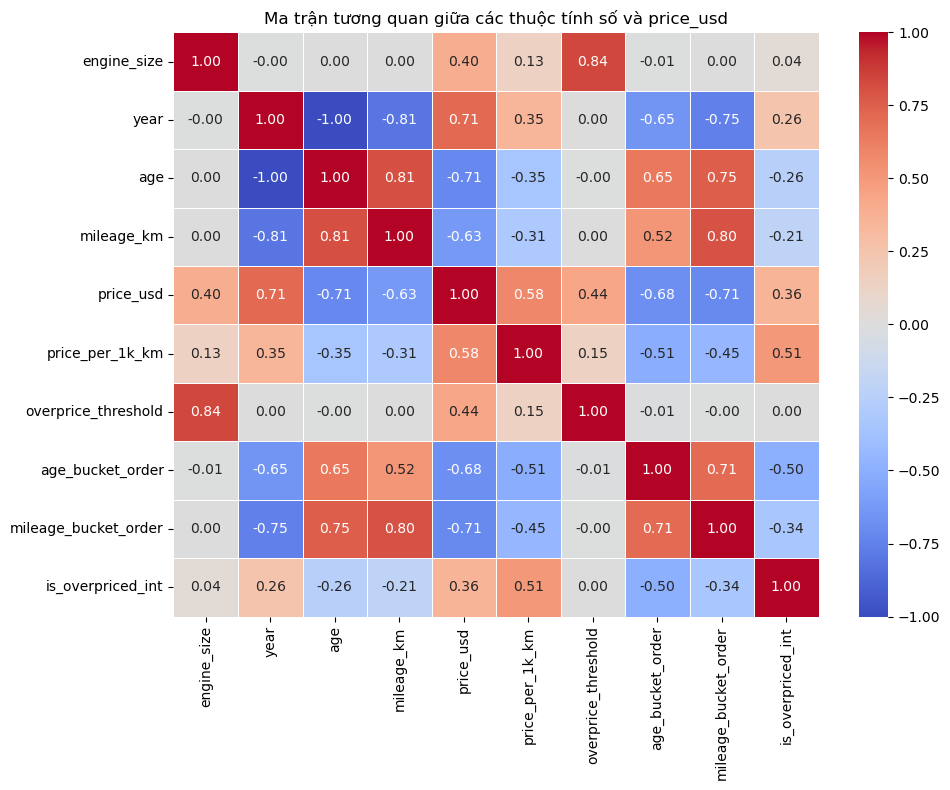

In [6]:
corr_matrix = df[numeric_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Ma trận tương quan giữa các thuộc tính số và price_usd")
plt.tight_layout()
plt.show()

- `age` có tương quan **âm khá mạnh** với `price_usd` (≈ −0.71): xe càng cũ thì giá càng giảm.
- `mileage_km` cũng tương quan âm với `price_usd` (≈ −0.63): xe chạy càng nhiều km thì giá càng rẻ.
- `engine_size` tương quan dương với `price_usd` (≈ +0.40): dung tích động cơ lớn thường đi kèm với giá cao hơn.
- `year` tương quan **dương mạnh** với `price_usd` (≈ +0.71), đồng thời `year` và `age` có tương quan ≈ −1.00  
  → hai biến này thực chất mang cùng một thông tin “thời gian sử dụng”, chỉ khác dấu.
- Các biến `age_bucket_order`, `mileage_bucket_order` tương quan rất mạnh với `age` và `mileage_km`, cho thấy chúng chỉ là phiên bản rời rạc hóa (bucket) của hai biến gốc.
- Các biến dẫn xuất từ giá như `price_per_1k_km`, `overprice_threshold`, `is_overpriced_int` có tương quan khá cao với `price_usd`, nhưng đây là những biến **được tính trực tiếp từ giá**, nếu dùng làm input sẽ gây **data leakage** (mô hình “nhìn trước đáp án”).

- Ngoài ma trận tương quan, nhóm cũng vẽ thêm các biểu đồ scatter

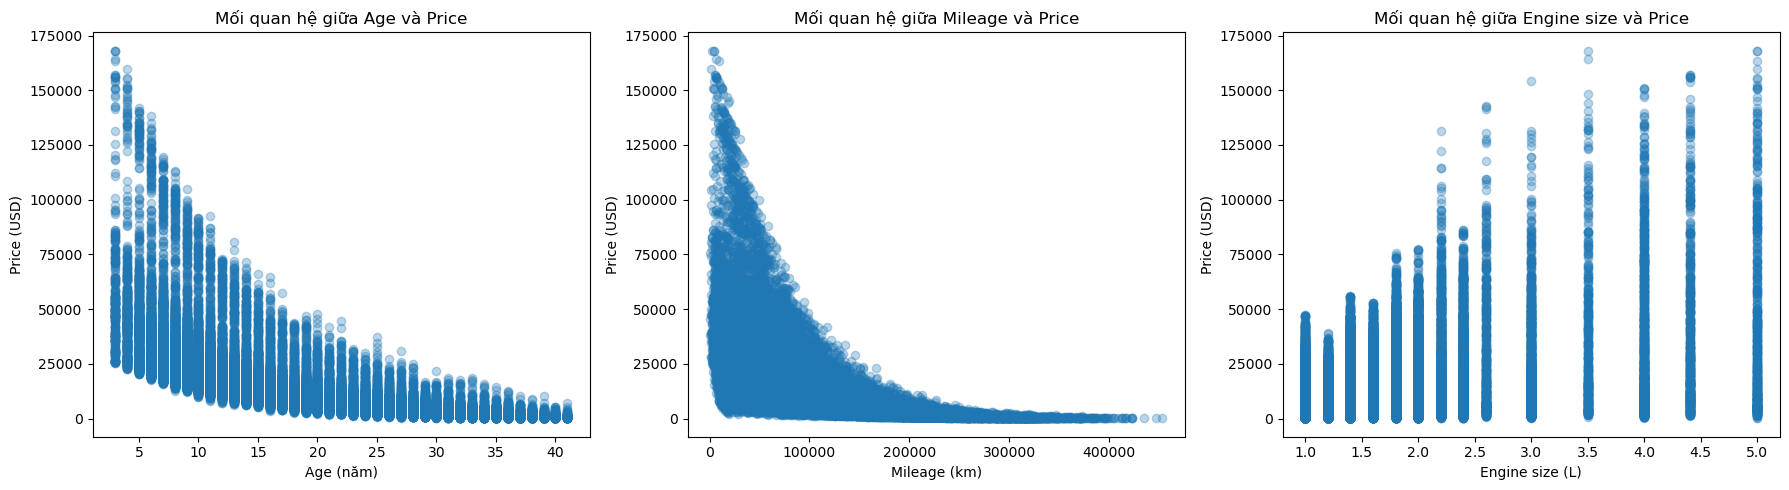

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# age vs price_usd
if 'age' in df.columns:
    axes[0].scatter(df['age'], df['price_usd'], alpha=0.3)
    axes[0].set_xlabel("Age (năm)")
    axes[0].set_ylabel("Price (USD)")
    axes[0].set_title("Mối quan hệ giữa Age và Price")

# mileage_km vs price_usd
if 'mileage_km' in df.columns:
    axes[1].scatter(df['mileage_km'], df['price_usd'], alpha=0.3)
    axes[1].set_xlabel("Mileage (km)")
    axes[1].set_ylabel("Price (USD)")
    axes[1].set_title("Mối quan hệ giữa Mileage và Price")

# engine_size vs price_usd
if 'engine_size' in df.columns:
    axes[2].scatter(df['engine_size'], df['price_usd'], alpha=0.3)
    axes[2].set_xlabel("Engine size (L)")
    axes[2].set_ylabel("Price (USD)")
    axes[2].set_title("Mối quan hệ giữa Engine size và Price")

plt.tight_layout()
plt.show()

==> Quan sát các biểu đồ này, ta có nhận xét:
+ Age càng tăng -> Price càng giảm
+ Mileage càng tăng -> Price càng giảm
+ Engine size càng tăng -> Price càng tăng

Những kết quả này khẳng định **`age`, `mileage_km` và `engine_size` là các biến số quan trọng nhất** để mô tả mối quan hệ với giá.

#### 2.2. Đánh giá thêm các biến phân loại `model` và `fuel_type`

Do là biến phân loại (categorical) nên `model` và `fuel_type` **không xuất hiện trực tiếp trong ma trận tương quan Pearson**. Để kiểm tra vai trò của chúng, nhóm:

- Vẽ **boxplot `price_usd` theo `fuel_type`**: phân bố giá giữa các loại nhiên liệu khác nhau có sự khác biệt nhất định.

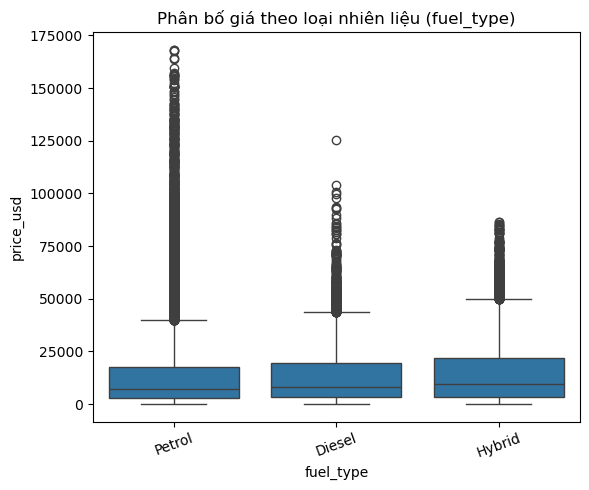

In [8]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='fuel_type', y='price_usd')
plt.title("Phân bố giá theo loại nhiên liệu (fuel_type)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

- Vẽ **boxplot `price_usd` theo `model`** (với một số model phổ biến): mỗi model có vùng giá riêng biệt, phản ánh đúng việc mỗi dòng xe/hãng xe thuộc phân khúc giá khác nhau.

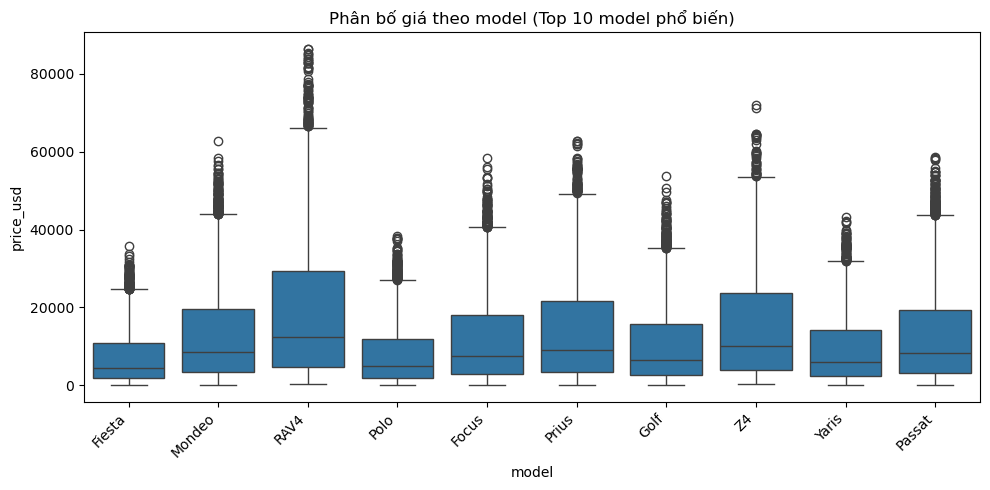

In [9]:
top_models = df['model'].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[df['model'].isin(top_models)],
    x='model', y='price_usd'
)
plt.title("Phân bố giá theo model (Top 10 model phổ biến)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Về mặt nghiệp vụ, điều này hoàn toàn hợp lý: **model** gần như gộp cả “hãng + dòng xe”, còn **fuel_type** ảnh hưởng tới chi phí vận hành và xu hướng thị trường (xăng/dầu/hybrid).

#### 2.3. Kết luận

Từ các phân tích trên, kết hợp với hiểu biết nghiệp vụ, nhóm đi đến quyết định:

- **Giữ lại làm đầu vào mô hình:**
  - `model`: thể hiện hãng + dòng xe, phân khúc giá.
  - `fuel_type`: loại nhiên liệu, ảnh hưởng đến định giá.
  - `engine_size`: dung tích động cơ, liên quan đến sức mạnh và phân khúc.
  - `age`: tuổi xe, thể hiện mức khấu hao theo thời gian.
  - `mileage_km`: số km đã chạy, thể hiện mức độ hao mòn thực tế.

- **Loại bỏ khỏi mô hình:**
  - `brand`: trùng thông tin với `model` (mỗi model thuộc đúng một brand), giữ cả hai sẽ làm tăng chiều dữ liệu và đa cộng tuyến.
  - `year`: mang cùng thông tin với `age` (tương quan gần −1), chỉ giữ `age` để tránh trùng lặp.
  - Các biến dẫn xuất từ giá (`price_per_1k_km`, `overprice_threshold`, `is_overpriced`, các bucket): tuy tương quan cao với `price_usd` nhưng được tính trực tiếp từ giá, nếu đưa vào mô hình sẽ gây **rò rỉ dữ liệu** và không phản ánh đúng bài toán thực tế (dự đoán giá khi chưa biết các biến này).

Như vậy, bộ thuộc tính **`model`, `fuel_type`, `engine_size`, `age`, `mileage_km`** vừa đảm bảo:
- Bao quát được các yếu tố quan trọng nhất ảnh hưởng tới giá xe (phân khúc, cấu hình, tuổi, mức sử dụng),
- Vừa tránh trùng lặp và tránh sử dụng các biến “ăn gian” sinh ra từ chính `price_usd`.

Đây là cơ sở để khẳng định tập feature được lựa chọn là **hợp lý và cần thiết nhất** cho bài toán dự đoán giá xe trong đồ án.

### Bước 3: Lựa chọn các thuộc tính đầu vào và đầu ra cho mô hình

- Chọn các feature để huấn luyện mô hình.

In [10]:
features = ['model', 'fuel_type', 'engine_size', 'age', 'mileage_km']
target = 'price_usd'

data = df[features + [target]].copy()
print("Các cột dùng cho mô hình:", data.columns)

Các cột dùng cho mô hình: Index(['model', 'fuel_type', 'engine_size', 'age', 'mileage_km', 'price_usd'], dtype='object')


### Bước 4: Tiền xử lý dữ liệu cho mô hình

Sau khi đã lựa chọn được các thuộc tính đầu vào, bước tiếp theo là tiền xử lý dữ liệu để đưa về dạng phù hợp cho các mô hình học máy.

Các thao tác chính trong bước này gồm:

- **Tách tập train và test**: chia dữ liệu thành 2 phần, trong đó 80% dùng để huấn luyện (train), 20% dùng để kiểm tra (test). Việc này giúp đánh giá mô hình trên dữ liệu chưa từng thấy.
- **Mã hóa biến phân loại (One-Hot Encoding)**: các thuộc tính `model` và `fuel_type` là biến phân loại, nên được chuyển thành các biến nhị phân (0/1) để mô hình có thể xử lý được.
- **Chuẩn hóa các biến số (StandardScaler)**: các thuộc tính `engine_size`, `age`, `mileage_km` có đơn vị và khoảng giá trị khác nhau, được chuẩn hóa về cùng thang đo (mean = 0, std = 1). Điều này giúp các mô hình, đặc biệt là hồi quy tuyến tính và các mô hình dựa trên gradient, hội tụ nhanh và ổn định hơn.

Sau bước này, ta thu được các ma trận `X_train_prepared` và `X_test_prepared` sẵn sàng cho việc huấn luyện mô hình.

#### 4.1. Chia tập train & test

In [ ]:
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], "records;", "Test size:", X_test.shape[0], "records")

#### 4.2. Mã hóa one-hot cho các biến phân loại (model, fuel_type)

In [12]:
# Sử dụng OneHotEncoder của scikit-learn với drop='first' để tránh dummy trap
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_cat = ohe.fit_transform(X_train[['model', 'fuel_type']])
X_test_cat = ohe.transform(X_test[['model', 'fuel_type']])

In [13]:
# Lấy danh sách tên các feature sau khi one-hot
cat_feature_names = ohe.get_feature_names_out(['model', 'fuel_type'])
print("Số lượng features sau one-hot:", len(cat_feature_names))

Số lượng features sau one-hot: 16


#### 4.3. Chuẩn hóa các biến số (engine_size, age, mileage_km)

In [14]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[['engine_size', 'age', 'mileage_km']])
X_test_num = scaler.transform(X_test[['engine_size', 'age', 'mileage_km']])

#### 4.4. Kết hợp dữ liệu số và dữ liệu mã hóa thành ma trận đặc trưng cuối cùng

In [15]:
X_train_prepared = np.hstack([X_train_num, X_train_cat])
X_test_prepared = np.hstack([X_test_num, X_test_cat])

num_feature_names = ['engine_size', 'age', 'mileage_km']
feature_names = num_feature_names + list(cat_feature_names)

print("Kích thước ma trận X_train_prepared:", X_train_prepared.shape)
print("Kích thước ma trận X_test_prepared:", X_test_prepared.shape)

Kích thước ma trận X_train_prepared: (40000, 19)
Kích thước ma trận X_test_prepared: (10000, 19)


### Bước 5: Huấn luyện mô hình & đánh giá

Ở bước này, nhóm tiến hành huấn luyện nhiều mô hình hồi quy khác nhau trên tập train và đánh giá trên tập test để so sánh hiệu năng. Các mô hình được sử dụng gồm:

- **Linear Regression**: mô hình hồi quy tuyến tính cơ bản, làm chuẩn so sánh.
- **Decision Tree Regressor**: cây quyết định, có khả năng học được các quan hệ phi tuyến, nhưng dễ overfit nếu không kiểm soát độ sâu.
- **Random Forest Regressor**: rừng cây ngẫu nhiên, kết hợp nhiều cây quyết định để giảm overfit và cải thiện độ chính xác.
- **XGBoost Regressor**: mô hình boosting hiện đại, học tuần tự trên sai số của các cây trước đó, thường cho kết quả rất tốt trong các bài toán hồi quy.

Các mô hình được đánh giá bằng ba chỉ số:

- **RMSE (Root Mean Squared Error)**: căn bậc hai của MSE, đo sai số dự đoán, càng nhỏ càng tốt.
- **MAE (Mean Absolute Error)**: sai số tuyệt đối trung bình, cho biết trung bình mô hình dự đoán lệch bao nhiêu USD so với giá thực tế.
- **R² (hệ số xác định)**: thể hiện tỷ lệ phương sai của `price_usd` được mô hình giải thích; R² càng gần 1 thì mô hình càng “chính xác”.

Kết quả của từng mô hình được tổng hợp trong bảng `results` và vẽ biểu đồ cột để dễ so sánh.

#### 5.1. Huấn luyện mô hình Linear Regression

In [16]:
model_lr = LinearRegression()

model_lr.fit(X_train_prepared, y_train)
y_pred_lr = model_lr.predict(X_test_prepared)

In [17]:
# Tính các chỉ số đánh giá cho Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_lr, mae_lr, r2_lr))

Linear Regression - RMSE: 8868.26, MAE: 5786.31, R^2: 0.710


#### 5.2. Huấn luyện mô hình Decision Tree

In [18]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_prepared, y_train)
y_pred_dt = model_dt.predict(X_test_prepared)

In [19]:
# Tính các chỉ số đánh giá cho Decision Tree
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_dt, mae_dt, r2_dt))

Decision Tree - RMSE: 1064.29, MAE: 464.66, R^2: 0.996


#### 5.3. Huấn luyện mô hình Random Forest

In [20]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_prepared, y_train)
y_pred_rf = model_rf.predict(X_test_prepared)

In [21]:
# Tính các chỉ số đánh giá cho Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_rf, mae_rf, r2_rf))

Random Forest - RMSE: 676.93, MAE: 311.14, R^2: 0.998


#### 5.4. Huấn luyện mô hình XGBoost

In [22]:
model_xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model_xgb.fit(X_train_prepared, y_train)
y_pred_xgb = model_xgb.predict(X_test_prepared)

In [23]:
# Tính các chỉ số đánh giá cho XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost - RMSE: {:.2f}, MAE: {:.2f}, R^2: {:.3f}".format(rmse_xgb, mae_xgb, r2_xgb))

XGBoost - RMSE: 598.93, MAE: 349.95, R^2: 0.999


#### 5.5. Đánh giá các mô hình

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_xgb],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_xgb],
    'R2':  [r2_lr, r2_dt, r2_rf, r2_xgb]
})
results = results.set_index('Model')
print("Hiệu năng của các mô hình trên tập test:")
display(results)

Hiệu năng của các mô hình trên tập test:


,RMSE,MAE,R2
Model,,,
Linear Regression,8868.260690,5786.313143,0.710194
Decision Tree,1064.288638,464.661100,0.995826
Random Forest,676.930989,311.139586,0.998311
XGBoost,598.929227,349.945190,0.998678


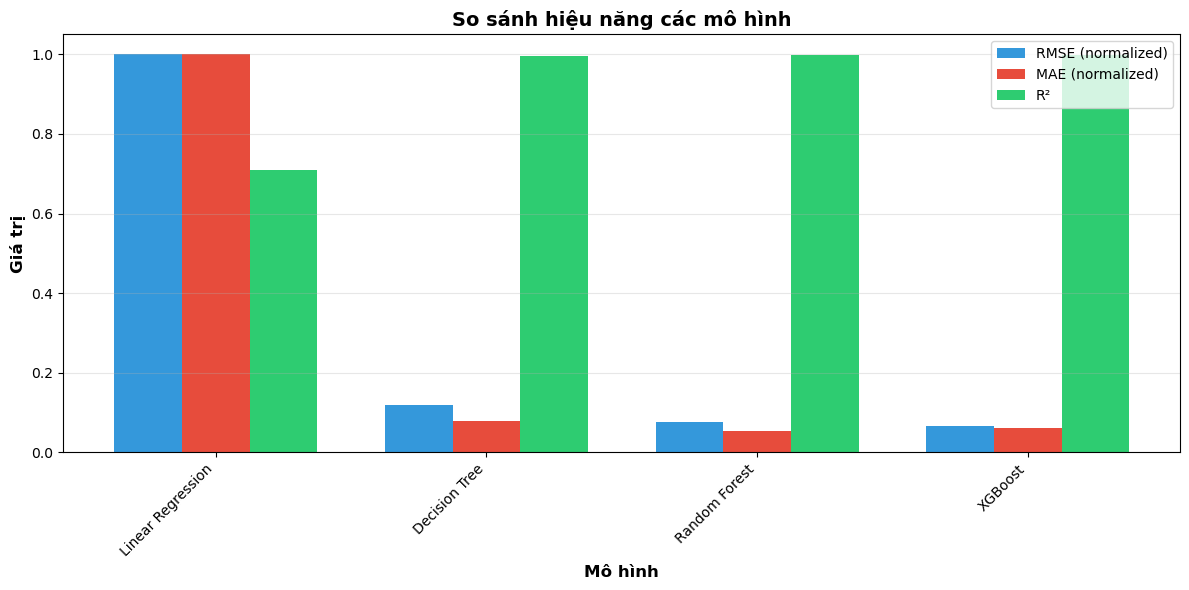

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results.index))
width = 0.25

rmse_normalized = results['RMSE'] / results['RMSE'].max()
mae_normalized = results['MAE'] / results['MAE'].max()

bars1 = ax.bar(x - width, rmse_normalized, width, label='RMSE (normalized)', color='#3498db')
bars2 = ax.bar(x, mae_normalized, width, label='MAE (normalized)', color='#e74c3c')
bars3 = ax.bar(x + width, results['R2'], width, label='R²', color='#2ecc71')

ax.set_xlabel('Mô hình', fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị', fontsize=12, fontweight='bold')
ax.set_title('So sánh hiệu năng các mô hình', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Bước 6: K-Fold Cross Validation để đánh giá khả năng tổng quát hóa

Đánh giá mô hình chỉ trên một lần chia train/test (80/20) có thể phụ thuộc vào cách “bốc thăm” dữ liệu.  
Để có cái nhìn khách quan hơn về khả năng tổng quát hóa, nhóm sử dụng **K-Fold Cross Validation** với:

- **K = 10**: chia tập train thành 10 phần (fold) gần bằng nhau.
- Mỗi lần lặp: dùng 9 fold để huấn luyện, 1 fold còn lại để kiểm tra.
- Lặp 10 lần sao cho mỗi mẫu đều được dùng làm dữ liệu kiểm tra đúng một lần.

Với mỗi mô hình (Linear Regression, Decision Tree, Random Forest, XGBoost), nhóm tính:

- **RMSE trung bình** và **độ lệch chuẩn RMSE** trên 10 fold.
- **R² trung bình** và **độ lệch chuẩn R²** trên 10 fold.

Bảng `cv_results` cho thấy Random Forest và XGBoost có RMSE trung bình thấp và R² trung bình cao, đồng thời độ lệch chuẩn nhỏ → hiệu năng tốt và ổn định hơn so với các mô hình còn lại.

- Thiết lập số fold cho K-Fold Cross Validation

In [26]:
k = 10
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

- Gom các mô hình lại thành dictionary để lặp

In [27]:
models_cv = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

cv_rows = []

for name, model in models_cv.items():
    neg_rmse_scores = cross_val_score(
        model,
        X_train_prepared,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kfold
    )
    
    r2_scores = cross_val_score(
        model,
        X_train_prepared,
        y_train,
        scoring="r2",
        cv=kfold
    )
    
    cv_rows.append({
        "Model": name,
        "CV_RMSE_Mean": -neg_rmse_scores.mean(),
        "CV_RMSE_Std":  neg_rmse_scores.std(),
        "CV_R2_Mean":   r2_scores.mean(),
        "CV_R2_Std":    r2_scores.std()
    })

cv_results = pd.DataFrame(cv_rows).set_index("Model")

print(f"Kết quả K-Fold Cross Validation (k = {k}):")
display(cv_results)

Kết quả K-Fold Cross Validation (k = 10):


,CV_RMSE_Mean,CV_RMSE_Std,CV_R2_Mean,CV_R2_Std
Model,,,,
Linear Regression,8737.370744,409.378542,0.715988,0.010069
Decision Tree,1094.362406,34.395829,0.995526,0.000388
Random Forest,734.426788,40.925668,0.997987,0.000200
XGBoost,645.863037,18.960734,0.998440,0.000150


### Bước 7: Trực quan hóa mô hình tốt nhất (XGBoost)


Từ các bước đánh giá ở trên, XGBoost là mô hình cho kết quả tốt nhất (RMSE thấp, R² cao).  
Để hiểu rõ hơn cách mô hình dự đoán, nhóm trực quan hóa:

- **Biểu đồ scatter giữa giá thực tế và giá dự đoán**:  
  Điểm nằm càng gần đường chéo y = x thì dự đoán càng chính xác. Nếu mô hình tốt, các điểm sẽ phân bố sát quanh đường này.

- **Biểu đồ histogram phân bố sai số (residuals)**:  
  Sai số được tính là `price_thực - price_dự_đoán`.  
  Nếu sai số phân bố đối xứng quanh 0 và không có nhiều giá trị ngoại lệ rất lớn, mô hình được xem là dự đoán tương đối ổn định.

Những biểu đồ này giúp kiểm tra trực quan xem mô hình có hệ thống thiên lệch nào hay không (ví dụ luôn dự đoán thấp hơn thực tế cho xe đắt tiền, v.v.).

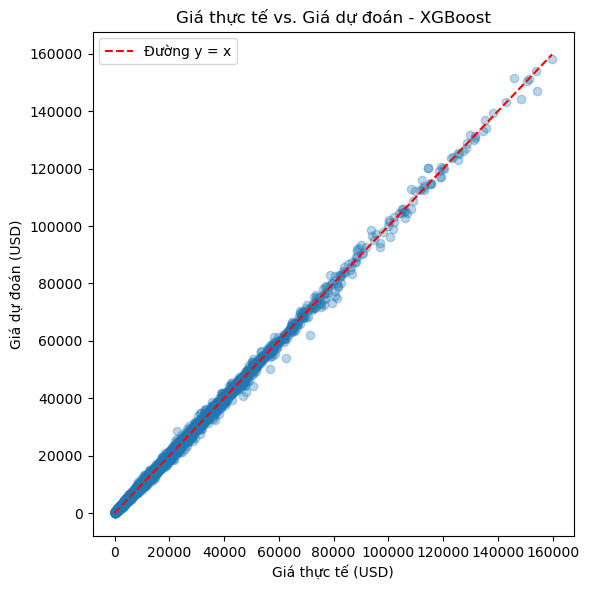

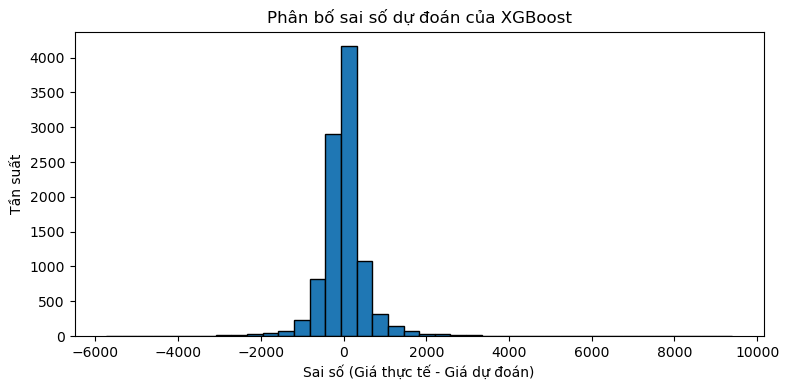

In [28]:
best_model = model_xgb
y_pred_best = y_pred_xgb

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Đường y = x")
plt.xlabel("Giá thực tế (USD)")
plt.ylabel("Giá dự đoán (USD)")
plt.title("Giá thực tế vs. Giá dự đoán - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - y_pred_best
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40, edgecolor="k")
plt.xlabel("Sai số (Giá thực tế - Giá dự đoán)")
plt.ylabel("Tần suất")
plt.title("Phân bố sai số dự đoán của XGBoost")
plt.tight_layout()
plt.show()

### Bước 8: Phân tích tầm quan trọng của thuộc tính (Feature Importance)

Cuối cùng, nhóm khai thác thêm thông tin từ các mô hình cây (Random Forest và XGBoost) bằng cách phân tích **tầm quan trọng của thuộc tính**:

- Đối với **Random Forest**, tầm quan trọng được tính dựa trên mức độ giảm độ “hỗn loạn” (impurity) khi tách dữ liệu theo từng thuộc tính, trung bình trên tất cả các cây trong rừng.
- Đối với **XGBoost**, tầm quan trọng được tính theo mức độ cải thiện hàm mất mát (gain) khi sử dụng thuộc tính đó để tách nhánh.

Nhóm vẽ biểu đồ cột top 15 thuộc tính quan trọng nhất cho mỗi mô hình.  
Kết quả cho thấy:

- Các thuộc tính **`age`**, **`mileage_km`** và một số biến one-hot tương ứng với **`model_*`** nằm trong nhóm quan trọng nhất → khẳng định lại rằng tuổi xe, số km chạy và dòng xe là các yếu tố chi phối mạnh đến giá.
- Thuộc tính **`engine_size`** cũng có trọng số đáng kể, phản ánh việc xe máy lớn thường giữ giá cao hơn.
- Các biến one-hot của **`fuel_type`** có tầm quan trọng thấp hơn nhưng vẫn đóng góp vào quyết định giá.

Phân tích feature importance vừa giúp giải thích mô hình (không còn là "hộp đen"), vừa củng cố tính hợp lý của tập thuộc tính đầu vào đã lựa chọn trước đó.

- Tầm quan trọng thuộc tính đối với Random Forest

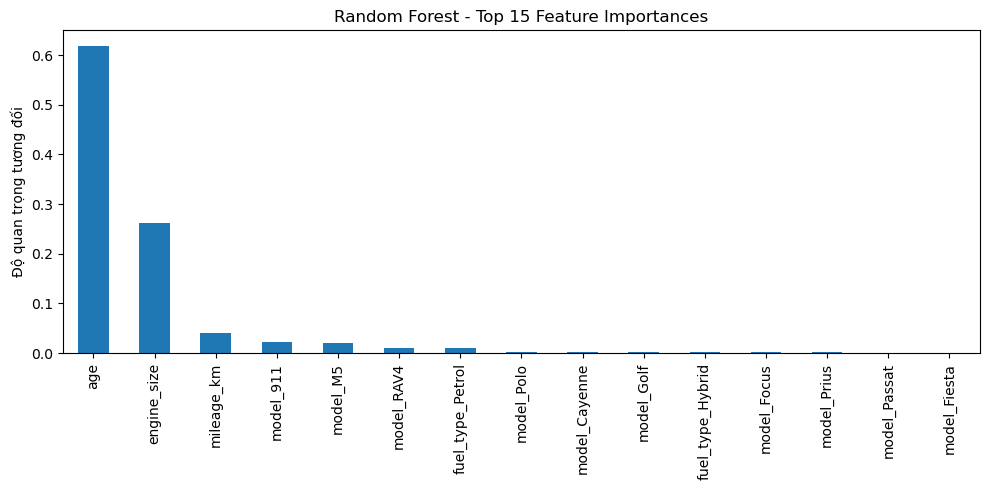

age                 0.618744
engine_size         0.262710
mileage_km          0.040125
model_911           0.021771
model_M5            0.020957
model_RAV4          0.010030
fuel_type_Petrol    0.009487
model_Polo          0.003046
model_Cayenne       0.002698
model_Golf          0.002601
fuel_type_Hybrid    0.001885
model_Focus         0.001546
model_Prius         0.001360
model_Passat        0.000918
model_Fiesta        0.000652
dtype: float64

In [29]:
rf_importances = model_rf.feature_importances_
fi_rf = pd.Series(rf_importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_rf.head(15).plot(kind="bar")
plt.title("Random Forest - Top 15 Feature Importances")
plt.ylabel("Độ quan trọng tương đối")
plt.tight_layout()
plt.show()

display(fi_rf.head(15))


- Tầm quan trọng thuộc tính đối với XGBoost

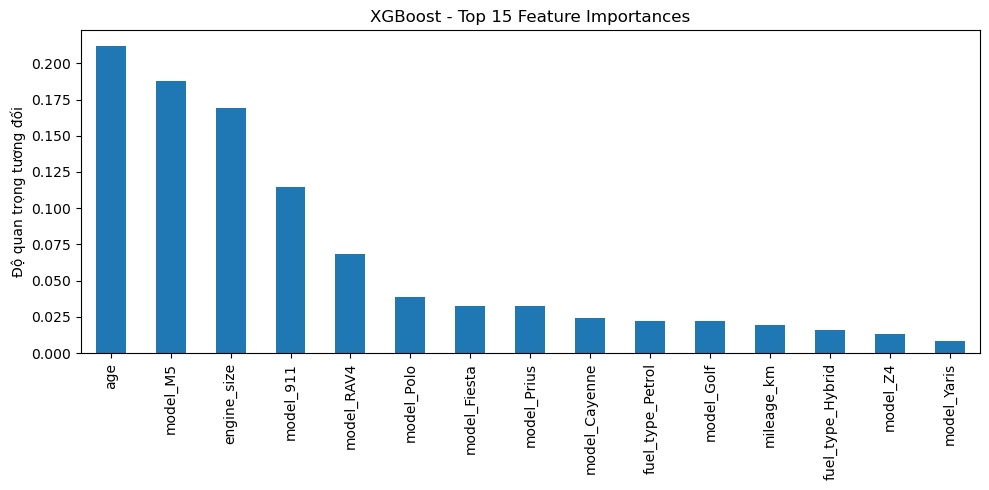

age                 0.212169
model_M5            0.187931
engine_size         0.169483
model_911           0.114758
model_RAV4          0.068304
model_Polo          0.038497
model_Fiesta        0.032394
model_Prius         0.032292
model_Cayenne       0.024041
fuel_type_Petrol    0.021997
model_Golf          0.021936
mileage_km          0.019441
fuel_type_Hybrid    0.015768
model_Z4            0.013037
model_Yaris         0.008106
dtype: float32

In [30]:
xgb_importances = model_xgb.feature_importances_
fi_xgb = pd.Series(xgb_importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_xgb.head(15).plot(kind="bar")
plt.title("XGBoost - Top 15 Feature Importances")
plt.ylabel("Độ quan trọng tương đối")
plt.tight_layout()
plt.show()

display(fi_xgb.head(15))